In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/climate_nasa (1).csv")

df.head()


,date,likesCount,profileName,commentsCount,text
0,2022-09-07T17:12:32.000Z,2,4dca617d86b3fdce80ba7e81fb16e048c9cd9798cdfd6d...,NaN,Neat comparison I have not heard it before.\n ...
1,2022-09-08T14:51:13.000Z,0,518ab97f2d115ba5b6f03b2fba2ef2b120540c9681288b...,NaN,An excellent way to visualise the invisible! T...
2,2022-09-07T17:19:41.000Z,1,d82e8e24eb633fd625b0aef9b3cb625cfb044ceb8483e1...,3.0,Does the CO2/ghg in the troposphere affect the...
3,2022-09-08T00:51:30.000Z,4,37a509fa0b5177a2233c7e2d0e2b2d6916695fa9fba3f2...,NaN,excellent post! I defo feel the difference - o...
4,2022-09-07T19:06:20.000Z,16,e54fbbd42a729af9d04d9a5cc1f9bbfe8081a31c219ecb...,26.0,"Yes, and carbon dioxide does not harm the Eart..."


In [2]:


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           522 non-null    object 
 1   likesCount     522 non-null    int64  
 2   profileName    522 non-null    object 
 3   commentsCount  244 non-null    float64
 4   text           504 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.5+ KB


In [3]:
df.shape


(522, 5)

In [4]:

df.columns

Index(['date', 'likesCount', 'profileName', 'commentsCount', 'text'], dtype='object')

In [5]:
df.isnull().sum()


,0
date,0
likesCount,0
profileName,0
commentsCount,278
text,18


In [6]:

df.duplicated().sum()

np.int64(0)

In [7]:
df['text'].str.strip().eq('').sum()


np.int64(0)

In [8]:
df_clean = df.dropna(subset=['text'])

df_clean.shape


(504, 5)

In [9]:
df_clean['date'] = pd.to_datetime(df_clean['date'])

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 504 entries, 0 to 521
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   date           504 non-null    datetime64[ns, UTC]
 1   likesCount     504 non-null    int64              
 2   profileName    504 non-null    object             
 3   commentsCount  242 non-null    float64            
 4   text           504 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(2)
memory usage: 23.6+ KB


/tmp/ipython-input-4255476423.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date'] = pd.to_datetime(df_clean['date'])


In [10]:
df_clean['text_length'] = df_clean['text'].apply(len)

df_clean['text_length'].describe()


/tmp/ipython-input-1438225029.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['text_length'] = df_clean['text'].apply(len)


,text_length
count,504.000000
mean,185.432540
std,528.078617
min,1.000000
25%,41.750000
50%,92.000000
75%,184.000000
max,7649.000000


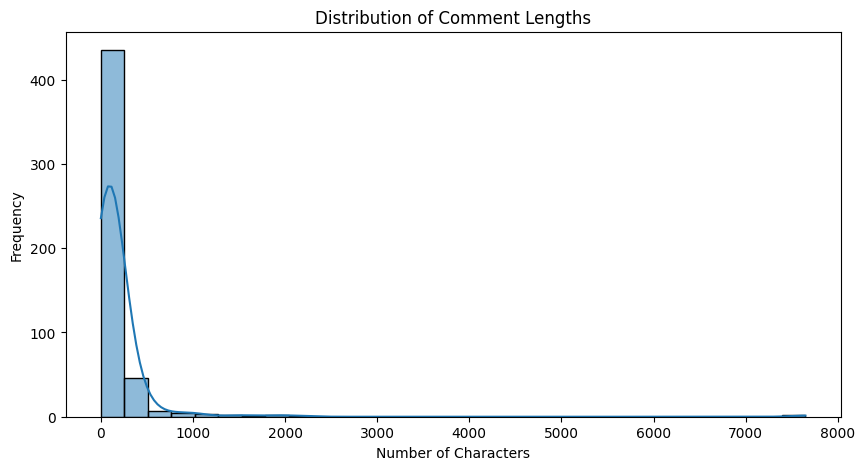

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['text_length'], bins=30, kde=True)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


In [12]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df_clean['clean_text'] = df_clean['text'].apply(clean_text)

df_clean[['text', 'clean_text']].head()


/tmp/ipython-input-946626979.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['clean_text'] = df_clean['text'].apply(clean_text)


,text,clean_text
0,Neat comparison I have not heard it before.\n ...,neat comparison i have not heard it before\n i...
1,An excellent way to visualise the invisible! T...,an excellent way to visualise the invisible th...
2,Does the CO2/ghg in the troposphere affect the...,does the coghg in the troposphere affect the s...
3,excellent post! I defo feel the difference - o...,excellent post i defo feel the difference one...
4,"Yes, and carbon dioxide does not harm the Eart...",yes and carbon dioxide does not harm the earth...


In [13]:
df_clean = df_clean.copy()

df_clean.loc[:, 'clean_text'] = df_clean['text'].apply(clean_text)

df_clean[['text', 'clean_text']].head()


,text,clean_text
0,Neat comparison I have not heard it before.\n ...,neat comparison i have not heard it before\n i...
1,An excellent way to visualise the invisible! T...,an excellent way to visualise the invisible th...
2,Does the CO2/ghg in the troposphere affect the...,does the coghg in the troposphere affect the s...
3,excellent post! I defo feel the difference - o...,excellent post i defo feel the difference one...
4,"Yes, and carbon dioxide does not harm the Eart...",yes and carbon dioxide does not harm the earth...


In [14]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df_clean['sentiment_score'] = df_clean['clean_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

df_clean[['clean_text', 'sentiment_score']].head()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,clean_text,sentiment_score
0,neat comparison i have not heard it before\n i...,0.7702
1,an excellent way to visualise the invisible th...,0.7650
2,does the coghg in the troposphere affect the s...,0.2960
3,excellent post i defo feel the difference one...,0.1027
4,yes and carbon dioxide does not harm the earth...,0.6059


In [15]:
def sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['sentiment'] = df_clean['sentiment_score'].apply(sentiment_label)

df_clean[['sentiment_score', 'sentiment']].head()


,sentiment_score,sentiment
0,0.7702,Positive
1,0.7650,Positive
2,0.2960,Positive
3,0.1027,Positive
4,0.6059,Positive


In [16]:
df_clean['sentiment'].value_counts()


,count
sentiment,
Positive,194
Neutral,177
Negative,133


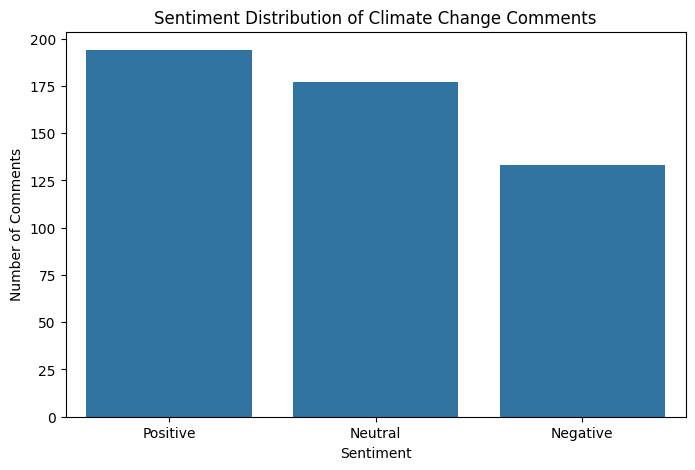

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df_clean, order=['Positive', 'Neutral', 'Negative'])
plt.title("Sentiment Distribution of Climate Change Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()


In [18]:
df_clean.groupby('sentiment')['likesCount'].mean()


,likesCount
sentiment,
Negative,7.142857
Neutral,1.988701
Positive,5.938144


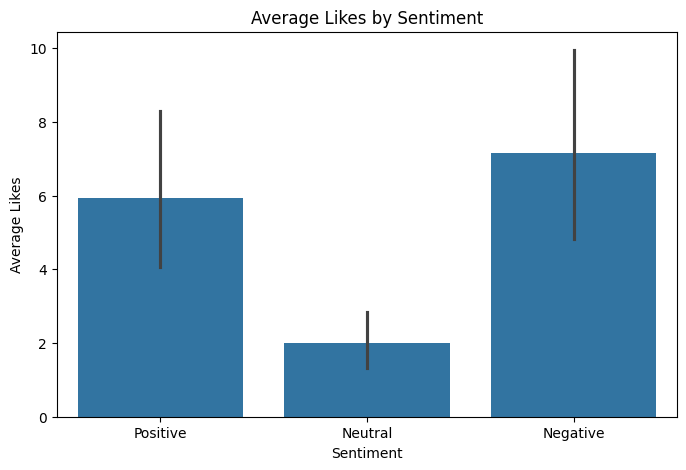

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x='sentiment',
    y='likesCount',
    data=df_clean,
    order=['Positive', 'Neutral', 'Negative']
)
plt.title("Average Likes by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Likes")
plt.show()


In [20]:
df_clean.groupby('sentiment')['commentsCount'].mean()


,commentsCount
sentiment,
Negative,11.730159
Neutral,7.060976
Positive,8.185567


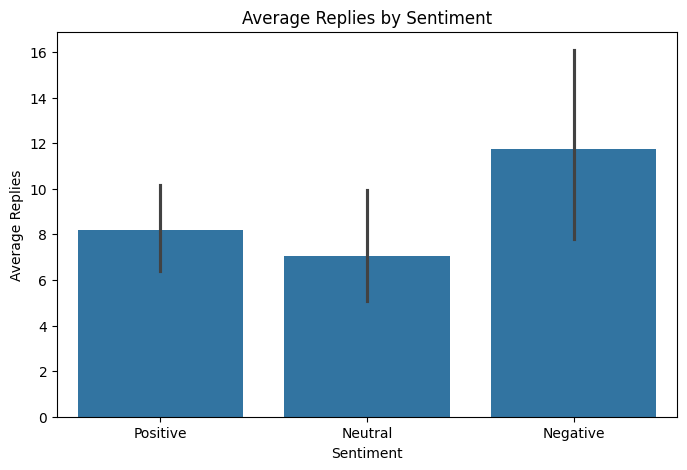

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x='sentiment',
    y='commentsCount',
    data=df_clean,
    order=['Positive', 'Neutral', 'Negative']
)
plt.title("Average Replies by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Replies")
plt.show()


In [22]:
df_clean['year_month'] = df_clean['date'].dt.to_period('M')

sentiment_time = (
    df_clean.groupby(['year_month', 'sentiment'])
    .size()
    .unstack(fill_value=0)
)

sentiment_time


/tmp/ipython-input-538701625.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_clean['year_month'] = df_clean['date'].dt.to_period('M')


sentiment,Negative,Neutral,Positive
year_month,,,
2020-09,36,57,57
2021-09,23,27,32
2021-10,7,3,4
2021-11,8,7,11
2022-09,3,7,17
2022-10,9,8,13
2022-11,4,5,5
2022-12,19,17,26
2023-01,3,2,3


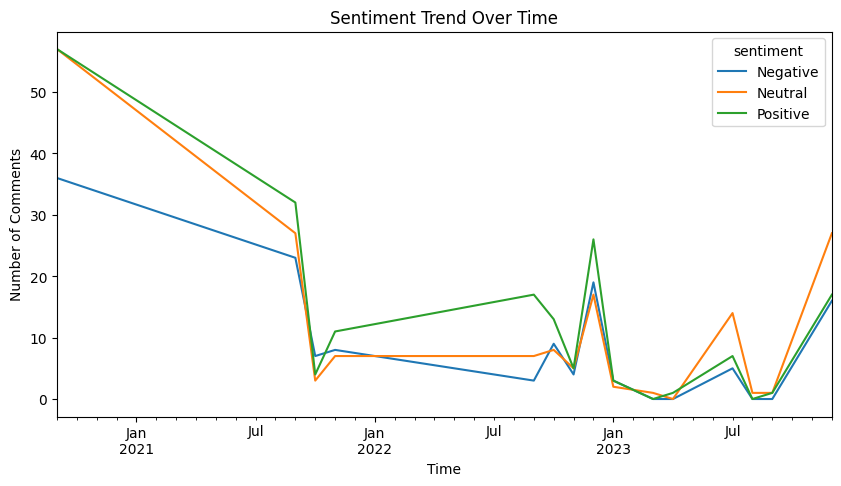

In [23]:
sentiment_time.plot(figsize=(10, 5))
plt.title("Sentiment Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Comments")
plt.show()


In [25]:
summary = pd.DataFrame({
    'Metric': [
        'Total Comments',
        'Positive Comments',
        'Neutral Comments',
        'Negative Comments',
        'Avg Likes (Positive)',
        'Avg Likes (Neutral)',
        'Avg Likes (Negative)',
        'Avg Replies (Positive)',
        'Avg Replies (Neutral)',
        'Avg Replies (Negative)'
    ],
    'Value': [
        len(df_clean),
        (df_clean['sentiment'] == 'Positive').sum(),
        (df_clean['sentiment'] == 'Neutral').sum(),
        (df_clean['sentiment'] == 'Negative').sum(),
        df_clean[df_clean['sentiment']=='Positive']['likesCount'].mean(),
        df_clean[df_clean['sentiment']=='Neutral']['likesCount'].mean(),
        df_clean[df_clean['sentiment']=='Negative']['likesCount'].mean(),
        df_clean[df_clean['sentiment']=='Positive']['commentsCount'].mean(),
        df_clean[df_clean['sentiment']=='Neutral']['commentsCount'].mean(),
        df_clean[df_clean['sentiment']=='Negative']['commentsCount'].mean()
    ]
})

summary


,Metric,Value
0,Total Comments,504.000000
1,Positive Comments,194.000000
2,Neutral Comments,177.000000
3,Negative Comments,133.000000
4,Avg Likes (Positive),5.938144
5,Avg Likes (Neutral),1.988701
6,Avg Likes (Negative),7.142857
7,Avg Replies (Positive),8.185567
8,Avg Replies (Neutral),7.060976
9,Avg Replies (Negative),11.730159



This project analyzed public opinions on climate change using comments collected from NASA’s Facebook page.
Natural Language Processing techniques were applied to clean and process textual data, followed by sentiment
analysis using the VADER sentiment analyzer. The results indicate that public sentiment is slightly positive
overall, with a substantial presence of neutral and negative viewpoints. Engagement analysis revealed that
negative comments tend to receive higher likes and replies, suggesting that critical opinions generate stronger
interaction and discussion. Time-based analysis showed variations in sentiment across posting periods,
highlighting the dynamic nature of public discourse on climate change. This study demonstrates how NLP can be
effectively used to understand public opinion and engagement patterns on social media platforms.
